In [1]:
# from LadrunoGraphStyle import set_default_plot_params, main_colors
# set_default_plot_params()

In [2]:
from fem import (
    # Core
    Material,
    # Sections
    Membrane,
    # Gmsh tools
    GMSHtools,
    # Model
    FEMModel,
    # Elements
    CST, LST, Quad4, Quad9,
    # Units
    kgf, tf, kN, MPa, GPa, kg, g, cm, m, mm,
    # Parameters
    globalParameters,
)


import os
import numpy as np
import matplotlib.pyplot as plt
import gmsh
np.set_printoptions(suppress=True, precision=6, linewidth=400)


  FEM -- Finite Element Method for Structural Analysis
  Based on the course by Prof. Jose Abell

  Version 1.2.0                        (c) 2026 All Rights Reserved

  Repository  :  https://github.com/ppalacios92/FEM
  Web Book    :  https://books.nmorabowen.com/books/fem

  Patricio Palacios B.    |    Nicolas Mora Bowen
  
  ********* (>'-')> Ladruno4ever  *********



In [3]:
globalParameters['nDoF'] = 2
globalParameters['nDIM'] = 2

In [4]:
# General model parameters
L = 5000 
H = 500  
B = 300
lc = 100
output_path = os.getcwd()
mesh_name = 'calibrated_beam'
output_file = os.path.join(output_path, mesh_name + '.msh')

if not os.path.exists(output_path):
    os.makedirs(output_path)

In [5]:
# Create a new GMSH model
gmsh.initialize()
gmsh.model.add(mesh_name)

# Corner points
p1 = gmsh.model.geo.addPoint(0,   0, 0, lc)
p2 = gmsh.model.geo.addPoint(L,   0, 0, lc)
p3 = gmsh.model.geo.addPoint(L,   H, 0, lc)
p4 = gmsh.model.geo.addPoint(0,   H, 0, lc)

# Mid points (bottom and top)
p5 = gmsh.model.geo.addPoint(L/2, 0, 0, lc)
p6 = gmsh.model.geo.addPoint(L/2, H, 0, lc)

# Lines
l1 = gmsh.model.geo.addLine(p1, p5)  # Bottom left
l2 = gmsh.model.geo.addLine(p5, p2)  # Bottom right
l3 = gmsh.model.geo.addLine(p2, p3)  # Right side
l4 = gmsh.model.geo.addLine(p3, p6)  # Top right
l5 = gmsh.model.geo.addLine(p6, p4)  # Top left
l6 = gmsh.model.geo.addLine(p4, p1)  # Left side
l7 = gmsh.model.geo.addLine(p5, p6)  # Center vertical

# Surfaces
c1 = gmsh.model.geo.addCurveLoop([l1,  l7, l5, l6])  # Left half
s1 = gmsh.model.geo.addPlaneSurface([c1])

c2 = gmsh.model.geo.addCurveLoop([l2, l3, l4, -l7])  # Right half
s2 = gmsh.model.geo.addPlaneSurface([c2])

gmsh.model.geo.synchronize()

# Physical groups
gmsh.model.addPhysicalGroup(2, [s1, s2], 201)
gmsh.model.setPhysicalName(2, 201, "Beam")

gmsh.model.addPhysicalGroup(0, [p1], 101)
gmsh.model.setPhysicalName(0, 101, "Support_left")

gmsh.model.addPhysicalGroup(0, [p2], 102)
gmsh.model.setPhysicalName(0, 102, "Support_right")

gmsh.model.addPhysicalGroup(0, [p6], 50)
gmsh.model.setPhysicalName(0, 50, "Load")

gmsh.model.geo.synchronize()

def all_quads():
    gmsh.model.geo.synchronize()
    gmsh.option.setNumber("Mesh.RecombineAll", 1)
    gmsh.option.setNumber("Mesh.Algorithm", 8)
    gmsh.option.setNumber("Mesh.RecombinationAlgorithm", 2)
    gmsh.option.setNumber("Mesh.Smoothing", 100)
    gmsh.option.setNumber("Mesh.ElementOrder", 2)

# all_quads()

In [6]:
# Generate the mesh
gmsh.model.mesh.generate()
# Save mesh to disk
gmsh.write(output_file)
# Open GMSH GUI
gmsh.fltk.run()
# Write mesh file again (redundant)
v = gmsh.write(output_file)
# Close GMSH instance
gmsh.finalize()

In [7]:
# Define material
fc=210
fc_21 = Material(name='fc_21',
                 E=13500*fc**0.5*kgf/cm**2,
                 nu=0.20,
                 rho= 2400*kg/m**3*g*0)

# Define membrane section
ConcreteBeam = Membrane(name='ConcreteBeam',
                        thickness=300,
                        material=fc_21)

# Map physical group IDs to sections
section_dictionary = {201: ConcreteBeam}

# Define distributed load magnitude
Pload = 10*tf

load_dictionary = {
    50:  {'value': Pload, 'direction': '-y'},   
}

# Define boundary conditions (restraints)
restrain_dictionary = {101: ['r', 'r'],
                       102: ['f', 'r']}


In [8]:
# read mesh 
mesh = GMSHtools(output_file)

  MESH SUMMARY

  === NODES ===  (364 total — showing first 3)
     Tag              x              y              z
--------------------------------------------------------------------------------
       1         0.0000         0.0000         0.0000
       2      5000.0000         0.0000         0.0000
       3      5000.0000       500.0000         0.0000
--------------------------------------------------------------------------------

  === PHYSICAL GROUPS ===  (4 total)
      ID    Dim   Name
--------------------------------------------------------------------------------
      50      0   'Load'
     101      0   'Support_left'
     102      0   'Support_right'
     201      2   'Beam'
--------------------------------------------------------------------------------

  === ELEMENTS ===  (4 groups)
      ID    Dim     Type   Nodes/el   N elements   Name
--------------------------------------------------------------------------------
      50      0       15          1            1  

In [9]:
mesh.node_map

{1: Node 1 at [0. 0.],
 2: Node 2 at [5000.    0.],
 3: Node 3 at [5000.  500.],
 4: Node 4 at [  0. 500.],
 5: Node 5 at [2500.    0.],
 6: Node 6 at [2500.  500.],
 7: Node 7 at [100.   0.],
 8: Node 8 at [200.   0.],
 9: Node 9 at [300.   0.],
 10: Node 10 at [400.   0.],
 11: Node 11 at [500.   0.],
 12: Node 12 at [600.   0.],
 13: Node 13 at [700.   0.],
 14: Node 14 at [800.   0.],
 15: Node 15 at [900.   0.],
 16: Node 16 at [1000.    0.],
 17: Node 17 at [1100.    0.],
 18: Node 18 at [1200.    0.],
 19: Node 19 at [1300.    0.],
 20: Node 20 at [1400.    0.],
 21: Node 21 at [1500.    0.],
 22: Node 22 at [1600.    0.],
 23: Node 23 at [1700.    0.],
 24: Node 24 at [1800.    0.],
 25: Node 25 at [1900.    0.],
 26: Node 26 at [2000.    0.],
 27: Node 27 at [2100.    0.],
 28: Node 28 at [2200.    0.],
 29: Node 29 at [2300.    0.],
 30: Node 30 at [2400.    0.],
 31: Node 31 at [2600.    0.],
 32: Node 32 at [2700.    0.],
 33: Node 33 at [2800.    0.],
 34: Node 34 at [2900

In [10]:
# por tag de gmsh
node = mesh.node_map[6]
print(node)

# o ver sus propiedades
node.print_summary()

Node 6 at [2500.  500.]

Node 6
  Coordinates : [2500.  500.]
  DOF indices : [10 11]
  Nodal load  : [0. 0.]
  Restraints  : ['f' 'f']




In [11]:
mesh.elements

{50: {'dim': 0,
  'gmsh_type': 15,
  'n_nodes': 1,
  'element_tags': [3],
  'connectivity': [[6]]},
 101: {'dim': 0,
  'gmsh_type': 15,
  'n_nodes': 1,
  'element_tags': [1],
  'connectivity': [[1]]},
 102: {'dim': 0,
  'gmsh_type': 15,
  'n_nodes': 1,
  'element_tags': [2],
  'connectivity': [[2]]},
 201: {'dim': 2,
  'gmsh_type': 2,
  'n_nodes': 3,
  'element_tags': [4,
   5,
   6,
   7,
   8,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54,
   55,
   56,
   57,
   58,
   59,
   60,
   61,
   62,
   63,
   64,
   65,
   66,
   67,
   68,
   69,
   70,
   71,
   72,
   73,
   74,
   75,
   76,
   77,
   78,
   79,
   80,
   81,
   82,
   83,
   84,
   85,
   86,
   87,
   88,
   89,
   90,
   91,
   92,
   93,
   94,


In [12]:
mesh.physical_groups["Beam"].elements


{'dim': 2,
 'gmsh_type': 2,
 'n_nodes': 3,
 'element_tags': [4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  149,
  150,
  151,
  152,


In [13]:
# Map number of nodes per element to element class
element_map = {
    3: CST,         # 3-node triangles
    4: Quad4,       # 4-node quadrilaterals
    6: LST,         # 6-node triangles
    9: Quad9,       # 9-node quadrilaterals
}

# Build FEM model — applies BCs, builds elements, assembles load vector
model = FEMModel(
    mesh                = mesh,
    section_dictionary  = section_dictionary,
    restrain_dictionary = restrain_dictionary,
    load_dictionary     = load_dictionary,
    element_class_map   = element_map,
    analysis_type       = 'planeStress',
    consistent_loads    = False,
    sampling_points     = 3,

    verbose=True,
)


  FEM MODEL SUMMARY
--------------------------------------------------------------------------------
  Analysis type    : planeStress
  Nodes            : 364
  system_nDof      : 728
  Elements         : 616
  Steps FEM        : 0
  Steps OpenSees   : 0

  --- Sections ---
  [201] Beam                  t=300  E=19185.79  nu=0.200

  --- Restrained nodes ---
  Node      1  [0. 0.]                         ['r', 'r']
  Node      2  [5000.    0.]                   ['f', 'r']

  --- Loaded nodes (dim=0) ---
  Node      6  [2500.  500.]                   F=[    -0. -98070.]

  --- Load vector ---
  Non-zero DOFs in F_load : 1
  Total applied force     : 0.0000 (x)  -98070.0000 (y)
--------------------------------------------------------------------------------



In [14]:
model.F_nodal

{6: array([    -0., -98070.])}

In [15]:
model.F_load

array([     0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0., -98070.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,
            0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.,      0.

In [16]:
model.system_nDof

728

In [17]:
# Mesh diagnostics
model.check_mesh()


  MESH DIAGNOSTICS
--------------------------------------------------------------------------------
  Nodes            : 364
  system_nDof      : 728
  Elements         : 616
  Physical groups  : 4

  --- Orphan nodes ---
  OK — no orphan nodes

  --- Physical groups ---
      ID   Dim  Name                    Elements     Nodes  Section
  ------  ----  --------------------  ----------  --------  ----------
      50     0  Load                           1         1  N/A
     101     0  Support_left                   1         1  N/A
     102     0  Support_right                  1         1  N/A
     201     2  Beam                         616       364  OK

  --- Restrained nodes ---
     Tag             x             y  Condition
  ------  ------------  ------------  ------------
       1        0.0000        0.0000  ['r', 'r']
       2     5000.0000        0.0000  ['f', 'r']

  --- Load summary ---
  Non-zero DOFs    : 1
  Total Fx         : +0.0000
  Total Fy         : -98070.0000

In [18]:
# Solve — single step
model.solve_static(
    n_steps=1, 
    load_factor=1.0,
    verbose = True,
)


  SOLVE SUMMARY
--------------------------------------------------------------------------------
  Steps solved     : 1
  Last load factor : 1.0000
  Max |ux|         : 1.230174
  Max |uy|         : 4.177557
  Max Von Mises    : 9.6770

  --- Equilibrium ---
  Applied  Fx: +0.0000   Reaction Rx: -0.0000   Balance: -4.5577e-08
  Applied  Fy: -98070.0000   Reaction Ry: +98070.0000   Balance: 1.4377e-08
--------------------------------------------------------------------------------



In [19]:
# Get node by tag and location
model.get_node(tags=[6, 10], 
               locations=[(2500, 250)],
               step = -1 , 
               );



  NODE RESULTS  (step=-1)
------------------------------------------------------------
     Tag  Coordinates                               ux            uy
  ------  ------------------------------  ------------  ------------
       6  [2500.  500.]                      +0.615081     -4.177557
      10  [400.   0.]                        +0.024297     -1.000702
     113  [2500.  300.]                      +0.615363     -4.166420
------------------------------------------------------------


In [20]:
# Get element by tag and location
model.get_element(tags=[6, 10], 
               locations=[(2500, 250)],
               step = -1 , 
               );



  ELEMENT RESULTS  (step=-1)
--------------------------------------------------------------------------------
     Tag  Centroid                   Type             Sxx         Syy         Sxy          VM
  ------  -------------------------  --------  ----------  ----------  ----------  ----------
       6  [2318.68  352.68]          CST          -3.3936     -0.1581     -0.9223      3.6820
      10  [2351.18  183.95]          CST           3.1076     -0.4807     -0.2981      3.4131
     405  [2527.28  248.11]          CST           0.2897     -0.5937      0.7104      1.4569
--------------------------------------------------------------------------------


In [21]:
# Node history — evolution over steps
uy_history = model.node_history(
    tag       = 6,
    component = 'uy',   # 'ux', 'uy', 'uz'
)

In [22]:
# Element history
sxx_history = model.element_history(
    tag       = 10,
    component = 'sxx',  # 'sxx','syy','sxy','exx','eyy','exy','vm'
)

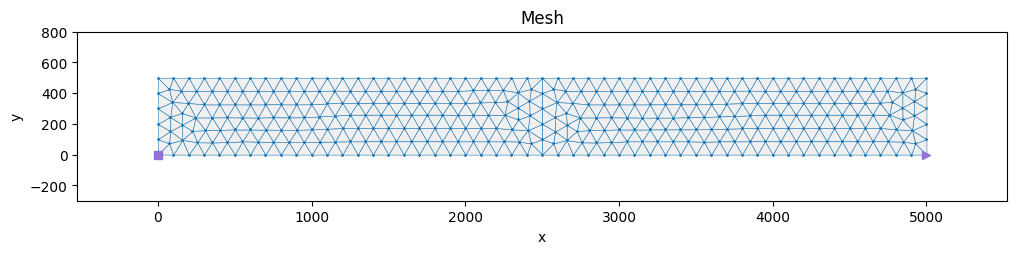

In [23]:
# Plot mesh
model.plot(
    step                = -1,
    show_node_labels    = False,
    show_element_labels = False,
    show_supports       = True,
    show_element_edges  = True,
    show_node_points    = True,
    figsize             = (12, 8),
)

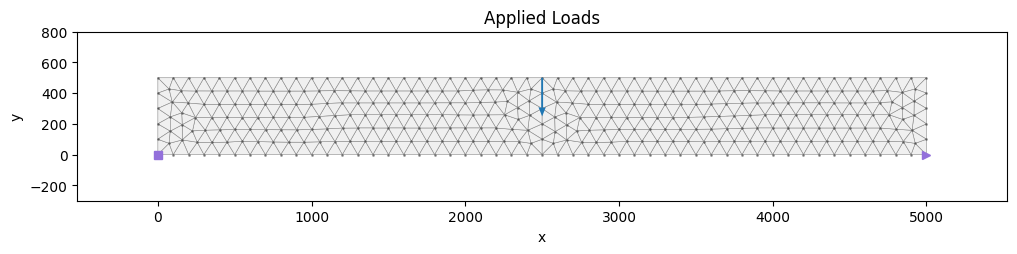

In [24]:
# Plot loads
model.plot_loads(
    show_element_edges = True,
    show_node_points   = True,
    show_supports      = True,
    figsize            = (12, 8),
)

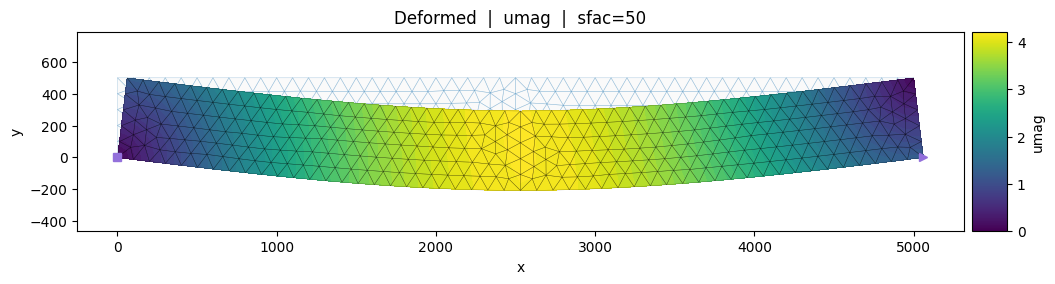

In [25]:
# Plot deformed
model.plot_deformed(
    sfac                = 50,
    step                = -1,
    component           = 'umag',   # 'ux', 'uy', 'umag'
    cmap                = 'viridis',
    show_element_edges  = True,
    show_supports       = True,
    figsize             = (12, 8),
)

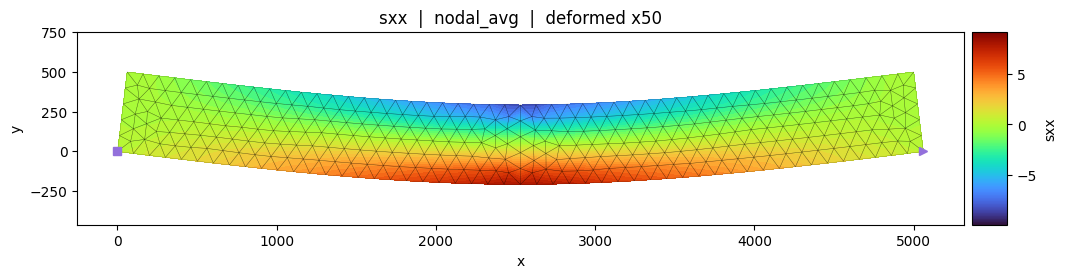

In [26]:
# Plot field
model.plot_field(
    component           = 'sxx',        # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy'
    source              = 'fem',
    step                = -1,
    result_type         = 'nodal_avg',  # 'nodal_avg' or 'element'
    deformed            = True,
    sfac                = 50,
    cmap                = 'turbo',
    show_element_edges  = True,
    show_supports       = True,
    figsize             = (12, 8),
)

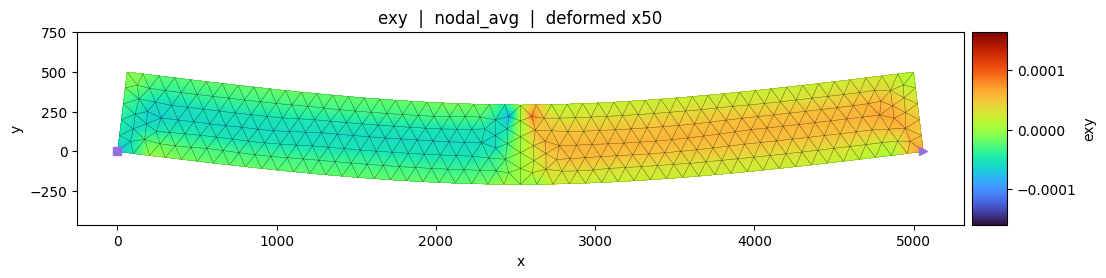

In [27]:
# Plot field
model.plot_field(
    component           = 'exy',        # 'sxx','syy','sxy','vmis','s1','s2','exx','eyy','exy'
    source              = 'fem',
    step                = -1,
    result_type         = 'nodal_avg',  # 'nodal_avg' or 'element'
    deformed            = True,
    sfac                = 50,
    cmap                = 'turbo',
    show_element_edges  = True,
    show_supports       = True,
    figsize             = (12, 8),
)

In [28]:
# Send to gmsh — static
model.plot2gmsh(
    step            = -1,
    source         = 'fem',
    disp_factor     = 50,
    show_disp       = True,
    show_loads      = True,
    show_reactions  = True,
    show_stress     = True,
    show_strain     = True,
    show_vm         = True,
    show_averaged   = True,

)

In [29]:
# Send to gmsh — animation of all steps
model.plot2gmsh_animate(
    disp_factor=10
)

In [30]:
# Save results to HDF5
output_file_h5 = os.path.join(output_path, mesh_name + '.h5')
model.save(output_file_h5)

In [31]:
# Load results from HDF5
results = FEMModel.load_results(output_file_h5)


  NODE HISTORY  —  uy
------------------------------------------------------------
     Tag  Coordinates                              Min           Max         Final
  ------  ------------------------------  ------------  ------------  ------------
       6  [2500.  500.]                      -4.177557     -4.177557     -4.177557
      10  [400.   0.]                        -1.000702     -1.000702     -1.000702
      15  [900.   0.]                        -2.143543     -2.143543     -2.143543
     113  [2500.  300.]                      -4.166420     -4.166420     -4.166420
     109  [  0. 200.]                        -0.025449     -0.025449     -0.025449
------------------------------------------------------------


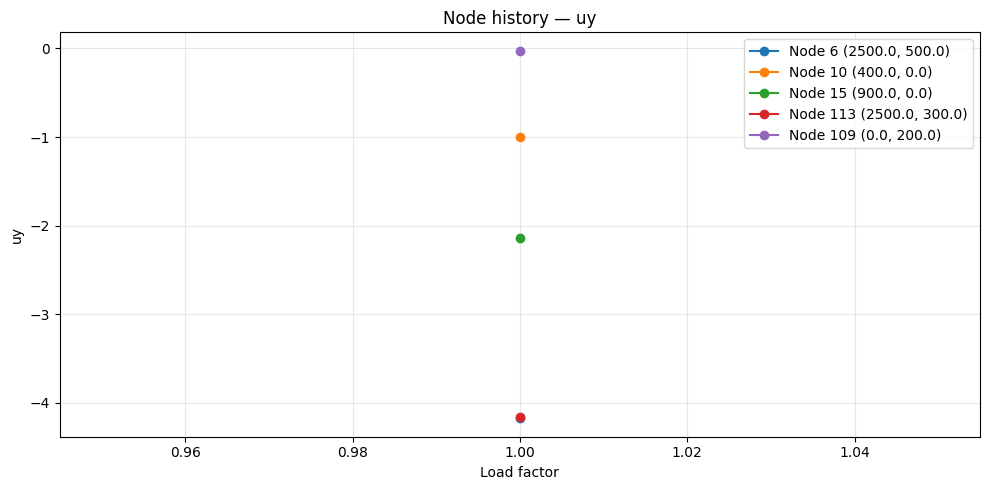


  ELEMENT HISTORY  —  sxx
--------------------------------------------------------------------------------
     Tag  Centroid                   Type               Min           Max         Final
  ------  -------------------------  --------  ------------  ------------  ------------
      10  [2351.18  183.95]          CST          +3.107649     +3.107649     +3.107649
      20  [999.37 272.63]            CST          +0.042120     +0.042120     +0.042120
     218  [2442.26   24.4 ]          CST          +9.125729     +9.125729     +9.125729
      20  [999.37 272.63]            CST          +0.042120     +0.042120     +0.042120
--------------------------------------------------------------------------------


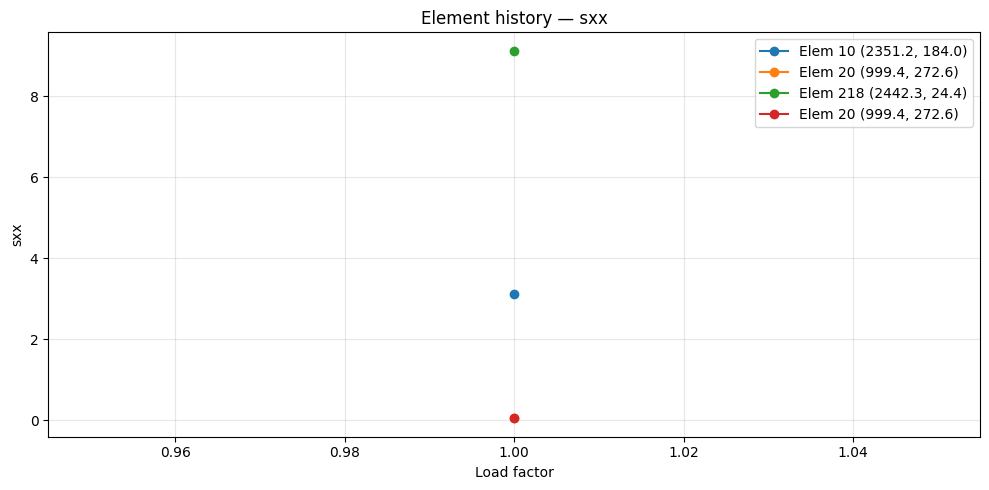

In [32]:
# por tags
model.plot_node_history(tags=[6, 10, 15], 
                        locations=[(2500, 250), (0, 250)],
                        component='uy')


# elementos
model.plot_element_history(tags=[10, 20], 
                           locations=[(2500, 0), (1000, 250)],
                           component='sxx')


## Opensees

In [33]:
import openseespy.opensees as ops
# import opensees as ops
import opsvis as opsv

ops.wipe()
ops.model('basicBuilder','-ndm',2,'-ndf',2)

In [34]:
# Nodes
for tag, (x, y, z) in mesh.nodes.items():
    ops.node(tag, x, y)

In [35]:
# Boundary conditions
for phys_id, condition in restrain_dictionary.items():
    if phys_id not in mesh.elements:
        continue
    for conn in mesh.elements[phys_id]['connectivity']:
        for tag in conn:
            ops.fix(tag, *[1 if r == 'r' else 0 for r in condition])

In [36]:
# Material
solidMaterialTag = 1

ops.nDMaterial('ElasticIsotropic', solidMaterialTag,
               fc_21.E,
               fc_21.nu,
               fc_21.rho)

In [37]:
# Elements
for phys_id, section in section_dictionary.items():
    if phys_id not in mesh.elements:
        continue
    group = mesh.elements[phys_id]
    for elem_tag, conn in zip(group['element_tags'], group['connectivity']):
        ops.element('tri31', elem_tag, *conn, section.thickness, 'PlaneStress', solidMaterialTag)

Tri31 - Written by Roozbeh G. Mikola and N.Sitar, UC Berkeley


<Axes: >

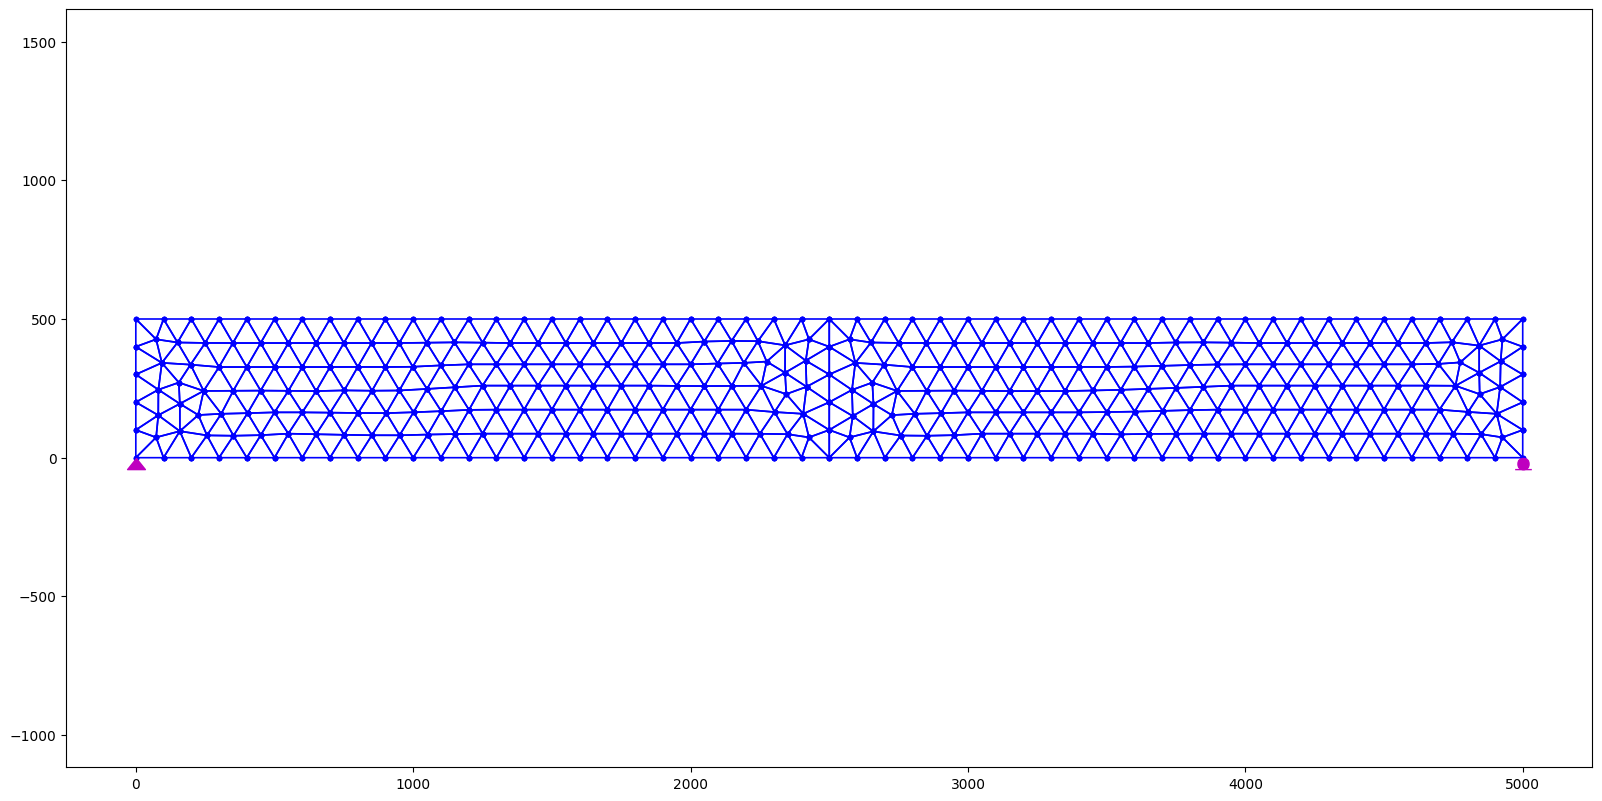

In [38]:
opsv.plot_model(node_labels=0, element_labels=0, fig_wi_he=(50,25))

In [39]:
# Loads
ts_tag      = 2
pattern_tag = 2
ops.timeSeries('Linear', ts_tag)
ops.pattern('Plain', pattern_tag, ts_tag)

for tag, force in model.F_nodal.items():
    if np.any(np.abs(force) > 0):
        ops.load(tag, *force.tolist())

In [40]:
NstepGravity=10
DGravity=1/NstepGravity

ops.system("FullGeneral")
ops.numberer("Plain")
ops.constraints("Plain")
ops.integrator("LoadControl", DGravity )
ops.test("NormUnbalance", 1.0e-6, 100 , 0)
ops.algorithm("Newton")
ops.analysis("Static")

ops.analyze(NstepGravity)

0

(10, <Axes: >)

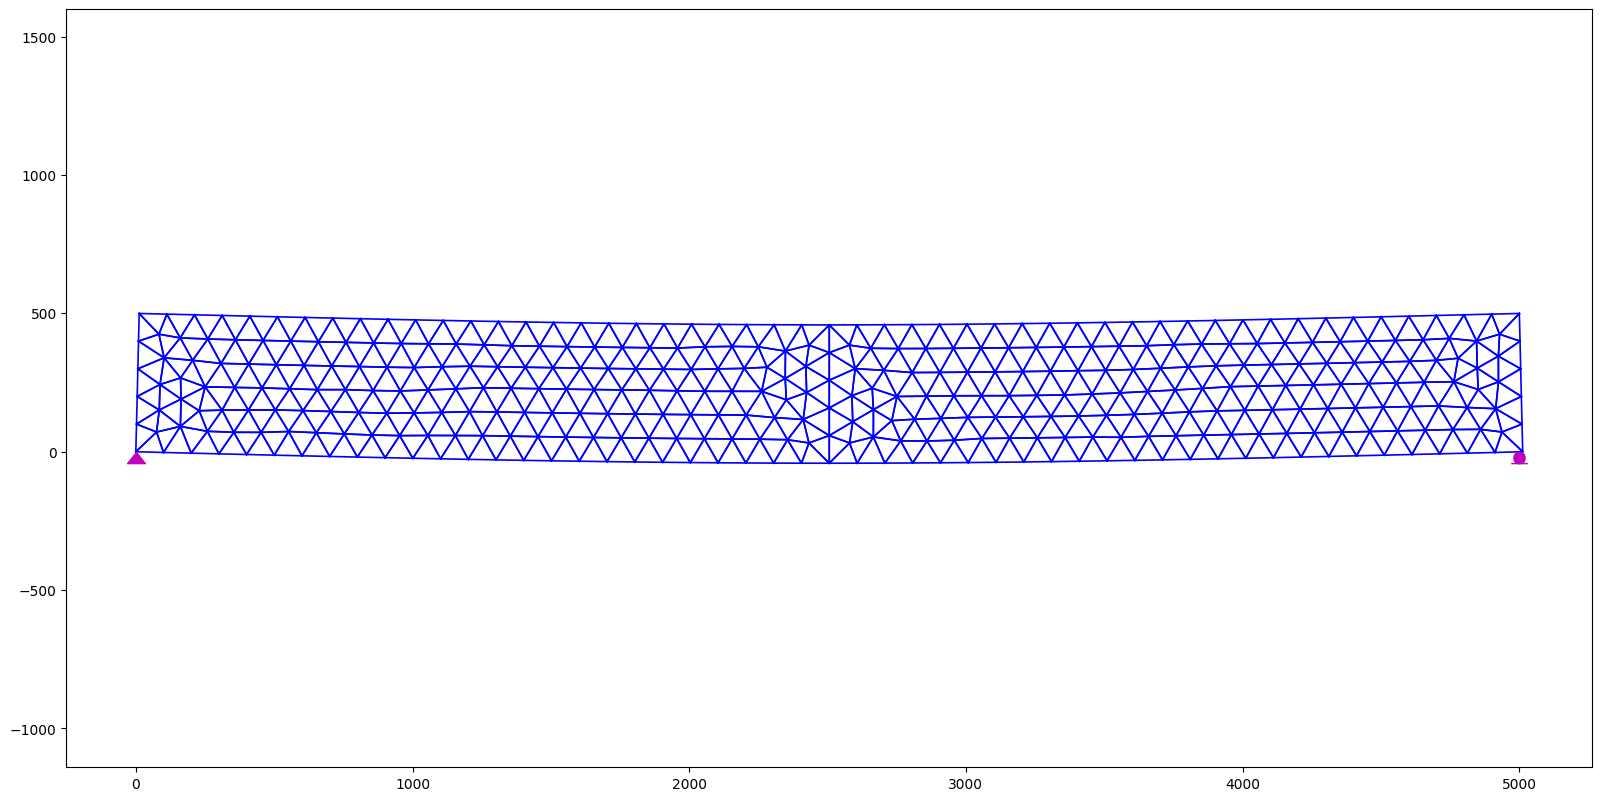

In [41]:
opsv.plot_defo(
    sfac=10,
    fig_wi_he=(50, 25),
    endDispFlag=True,
    unDefoFlag=0
)

Text(0.5, 1.0, 'sxx')

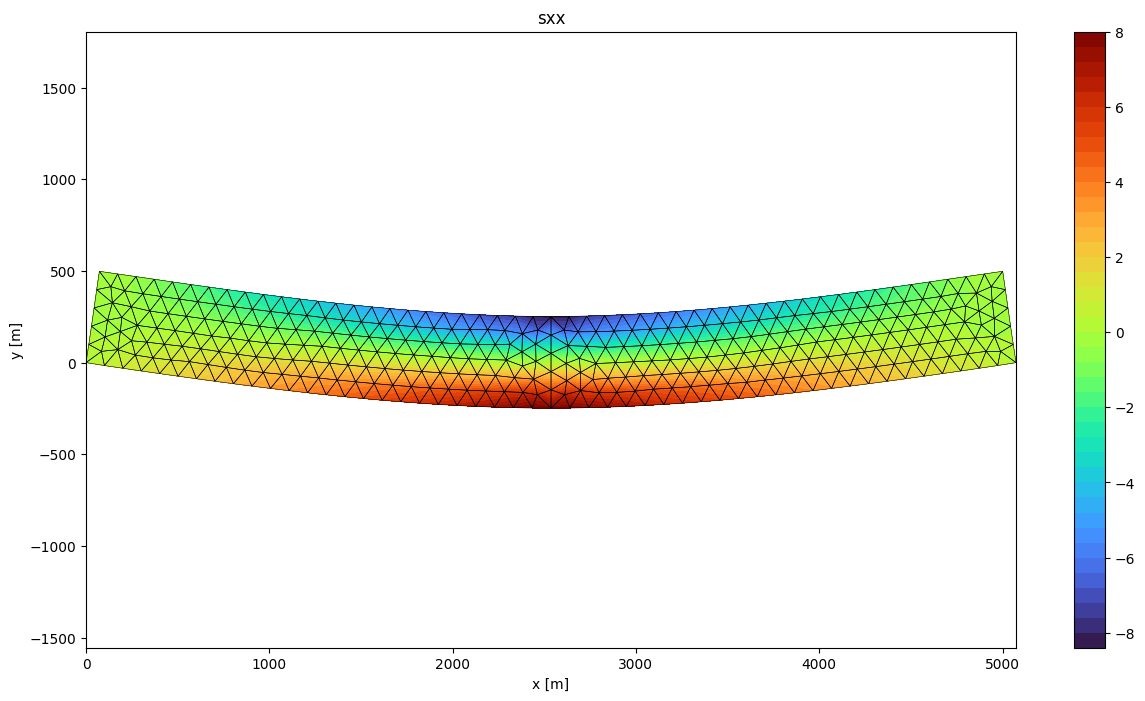

In [42]:
jstr = 'sxx'
# jstr = 'syy'
# jstr = 'sxy'
# jstr = 'vmis'
# jstr = 's1'
# jstr = 's2'
# jstr = 'angle'

plt.figure(figsize=(15, 8))
opsv.plot_stress(jstr)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
plt.title(f'{jstr}')

In [44]:
# Extract OpenSees results into model
model.set_results_opensees(
    ops              = ops,
    step             = 0,
)

# Visualize in gmsh
model.plot2gmsh(
    step           = -1,
    source         = 'opensees',
    disp_factor    = 50,
    show_disp      = True,
    show_loads     = True,
    show_reactions = True,
    show_stress    = True,
    show_strain    = True,
    show_vm        = True,
    show_averaged  = True,
)


In [46]:
# What's in the model
print(repr(model))
print(f"\nFEM steps     : {len(model.results_fem)}")
print(f"OpenSees steps: {len(model.results_opensees)}")
print(f"Modal modes   : {len(model.results_opensees_modal) if hasattr(model, 'results_opensees_modal') else 0}")

# Modal summary
if hasattr(model, 'results_opensees_modal'):
    print(f"\n  {'Mode':>6}  {'Freq [Hz]':>12}  {'Period [s]':>12}")
    for mr in model.results_opensees_modal:
        print(f"  {mr.mode:>6}  {mr.freq:>12.4f}  {mr.period:>12.4f}")

FEMModel | nodes=364 | elements=616 | steps_fem=1 | steps_opensees=2 | analysis=planeStress

FEM steps     : 1
OpenSees steps: 2
Modal modes   : 0
